# Phone KG Import Pipeline — Full

Pipeline hợp nhất: đọc cùng lúc **score data (list dict)** và **CSV (price/colors/specs)**,
import toàn bộ vào Neo4j theo schema:

```
Brand → Series → Model (base product)
                  ├── HAS_CONFIG    → ModelStorage (variant + giá)
                  ├── HAS_SPEC      → SpecCategory → SpecItem
                  ├── HAS_COLOR     → ColorVariant → ColorFamily
                  ├── HAS_QUALITY   → QualityProfile
                  ├── HAS_META      → PhoneMeta
                  ├── SUITABLE_FOR  → UseCase   {score}
                  └── TARGETS       → TargetUser {score}
```

**Thứ tự xử lý mỗi base SKU:**
1. Đọc score data → lấy base SKU
2. So khớp CSV → tìm product gốc + variants (chỉ khác storage suffix)
3. Import Model (base product) với đầy đủ specs, scores, meta
4. Import từng Variant (chỉ cần sku + giá)

---
**Yêu cầu:** `pip install neo4j pandas`

## 0. Setup & Connection

In [ ]:
# !pip install yfiles_jupyter_graphs
# !pip install neo4j pandas

In [1]:
import json
import re
import pandas as pd
from neo4j import GraphDatabase
from typing import Optional, List, Dict, Tuple

# ── Neo4j connection ───────────────────────────────────────────
NEO4J_URI      = "bolt://172.18.224.1:7687"
NEO4J_USER     = "neo4j"
NEO4J_PASSWORD = "12345678"

driver = GraphDatabase.driver(NEO4J_URI, auth=(NEO4J_USER, NEO4J_PASSWORD))
driver.verify_connectivity()
print("✅ Neo4j connected")

✅ Neo4j connected


## 1. Score Field Definitions

In [2]:
# ── UseCase: key trong list dict → tên node ────────────────────
USE_CASE_FIELDS = {
    'Gaming (Use Case)'             : 'Gaming',
    'Camera / Creator (Use Case)'   : 'Camera & Creator',
    'Văn phòng (Use Case)'          : 'Văn phòng',
    'Mạng xã hội (Use Case)'        : 'Mạng xã hội',
    'Thể thao / Outdoor (Use Case)' : 'Thể thao & Outdoor',
    'Thể thao / Outdoor (Đối tượng)': 'Thể thao & Outdoor',  # alias
    'Học tập (Use Case)'            : 'Học tập',
    'Kinh doanh (Use Case)'         : 'Kinh doanh',
}

# ── TargetUser: key trong list dict → tên node ─────────────────
TARGET_USER_FIELDS = {
    'Học tập (Đối tượng)'       : 'Học tập',
    'Kinh doanh (Đối tượng)'    : 'Kinh doanh',
    'Học sinh cấp 3 (Đối tượng)': 'Học sinh cấp 3',
    'Sinh viên (Đối tượng)'     : 'Sinh viên',
    'Dân văn phòng (Đối tượng)' : 'Dân văn phòng',
    'Freelancer (Đối tượng)'    : 'Freelancer',
    'Gamer (Đối tượng)'         : 'Gamer',
    'Nhiếp ảnh gia (Đối tượng)' : 'Nhiếp ảnh gia',
    'Người lớn tuổi (Đối tượng)': 'Người lớn tuổi',
    'Doanh nhân (Đối tượng)'    : 'Doanh nhân',
}

# ── Quality: key → property name trên QualityProfile node ──────
QUALITY_FIELDS = {
    'Chất lượng ảnh ban ngày'  : 'photo_day_score',
    'Chất lượng ảnh ban đêm'   : 'photo_night_score',
    'Chất lượng video thực tế' : 'video_score',
    'Chất lượng selfie thực tế': 'selfie_score',
}

# ── SpecCategory map (từ notebook gốc) ────────────────────────
SPEC_CATEGORY_MAP = {
    'Màn hình'                : 'man-hinh',
    'Camera sau'              : 'camera-sau',
    'Camera trước'            : 'camera-truoc',
    'Vi xử lý & đồ họa'      : 'chip',
    'Bộ xử lý & Đồ họa'      : 'chip',
    'Giao tiếp & kết nối'    : 'ket-noi',
    'RAM & lưu trữ'           : 'ram-luu-tru',
    'Pin & công nghệ sạc'     : 'pin',
    'Kích thước & Trọng lượng': 'thiet-ke',
    'Thiết kế & Trọng lượng'  : 'thiet-ke',
    'Thông số khác'           : 'thong-so-khac',
    'Tiện ích khác'           : 'tien-ich',
    'Tính năng khác'          : 'tinh-nang-khac',
    'Cổng kết nối'            : 'cong-ket-noi',
    'Thông tin chung'         : 'thong-tin-chung',
}

LENS_SPEC_NAMES = {
    'Camera sau', 'Camera chính', 'Telephoto', 'Góc siêu rộng',
    'Camera trước', 'Quay video', 'Quay video trước',
}

# ── Storage suffix patterns để nhận diện variant ───────────────
# CHỈ các suffix này mới được coi là variant của cùng base model
STORAGE_SUFFIXES = [
    '-64gb', '-128gb', '-256gb', '-512gb', '-1tb', '-2tb',
]
# RAM suffix (dành cho Android có RAM+Storage trong SKU)
RAM_SUFFIXES = [
    '-4gb', '-6gb', '-8gb', '-12gb', '-16gb',
]
ALL_VARIANT_SUFFIXES = STORAGE_SUFFIXES + RAM_SUFFIXES

print("✅ Field definitions ready")

✅ Field definitions ready


## 2. Helper Functions

In [3]:
# ── Price parser ───────────────────────────────────────────────
def parse_price(price_str) -> Optional[float]:
    """'36.990.000đ' → 36990000.0"""
    if not price_str or pd.isna(price_str):
        return None
    cleaned = re.sub(r'[^\d]', '', str(price_str))
    return float(cleaned) if cleaned else None


# ── Score parser ───────────────────────────────────────────────
def parse_score(value) -> Optional[int]:
    """'4 Rất tốt...' → 4, 'N/A' → None"""
    if value is None:
        return None
    s = str(value).strip()
    if s in ('N/A', '', 'Không đề cập', 'nan'):
        return None
    m = re.match(r'^(\d+)', s)
    if m:
        score = int(m.group(1))
        return score if 1 <= score <= 5 else None
    return None


def normalize_na(value) -> Optional[str]:
    """Chuẩn hóa N/A → None"""
    if value is None:
        return None
    s = str(value).strip()
    return None if s in ('N/A', '', 'nan', 'None') else s


# ── Extract số từ chuỗi spec ───────────────────────────────────
def extract_numeric(value_str: str) -> Optional[float]:
    m = re.search(r'([\d]+(?:[.,][\d]+)?)', str(value_str))
    return float(m.group(1).replace(',', '.')) if m else None


# ── Lens spec checker ──────────────────────────────────────────
def is_lens_spec(name: str) -> bool:
    return any(k.lower() in name.lower() for k in LENS_SPEC_NAMES)


# ── Chuẩn hóa SKU ─────────────────────────────────────────────
def normalize_sku(sku: str) -> str:
    return str(sku).strip().lower()


# ── Kiểm tra csv_sku có phải variant của base_sku không ────────
def is_storage_variant(base_sku: str, csv_sku: str) -> bool:
    """
    Rule: csv_sku là variant của base_sku KHI VÀ CHỈ KHI:
      csv_sku == base_sku + <storage_or_ram_suffix>
      VÀ suffix phải là một trong ALL_VARIANT_SUFFIXES

    Ví dụ:
      base='iphone-17-pro', csv='iphone-17-pro-256gb'  → True  (storage suffix)
      base='iphone-17',     csv='iphone-17-pro'        → False (không phải suffix storage)
      base='iphone-17',     csv='iphone-17-pro-256gb'  → False (suffix là '-pro-256gb')
    """
    if csv_sku == base_sku:
        return False  # exact match → đây là base, không phải variant

    # Suffix phần dôi ra sau base_sku
    if not csv_sku.startswith(base_sku):
        return False

    suffix = csv_sku[len(base_sku):]  # ví dụ: '-256gb', '-16gb-512gb'

    # suffix phải bắt đầu bằng '-' và toàn bộ là storage/RAM suffix
    # Cho phép combo như '-8gb-256gb' (RAM+Storage)
    remaining = suffix
    while remaining:
        matched = False
        for s in ALL_VARIANT_SUFFIXES:
            if remaining.startswith(s):
                remaining = remaining[len(s):]
                matched = True
                break
        if not matched:
            return False
    return True


# ── Parse storage GB từ SKU ────────────────────────────────────
def parse_storage_from_sku(sku: str) -> Optional[int]:
    """'iphone-17-pro-256gb' → 256, 'iphone-17-pro-1tb' → 1024"""
    m = re.search(r'-(\d+)(gb|tb)$', sku, re.IGNORECASE)
    if m:
        val  = int(m.group(1))
        unit = m.group(2).lower()
        return val * 1024 if unit == 'tb' else val
    return None


# ── Parse storage GB từ product name ──────────────────────────
def parse_storage_from_name(name: str) -> Optional[int]:
    """'iPhone 17 Pro Max 256GB' → 256"""
    m = re.search(r'(\d+)\s*(GB|TB)', name, re.IGNORECASE)
    if m:
        val  = int(m.group(1))
        unit = m.group(2).upper()
        return val * 1024 if unit == 'TB' else val
    return None


# ── Parse series từ SKU ────────────────────────────────────────
def parse_series_from_sku(base_sku: str, brand_name: str) -> dict:
    """
    Lấy series từ base_sku.
    Logic: bỏ các tier suffix (-pro, -pro-max, -plus, -air, -e, -ultra)
    để ra series name.

    Ví dụ:
      'iphone-17-pro-max' → series_id='iphone-17', series_name='iPhone 17'
      'iphone-17-e'       → series_id='iphone-17', series_name='iPhone 17'
      'samsung-s25-ultra' → series_id='samsung-s25', series_name='Samsung S25'
      'dien-thoai-meizu-mblu-note-21-pro' → series_id='meizu-mblu-note-21'
    """
    TIER_SUFFIXES = [
        '-pro-max', '-pro', '-plus', '-ultra', '-air',
        '-note', '-lite', '-fe',
    ]
    # Bỏ prefix 'dien-thoai-' nếu có
    clean_sku = re.sub(r'^dien-thoai-', '', base_sku)

    # Bỏ suffix '-e' chỉ nếu là cuối cùng (iphone-17-e → iphone-17)
    series_id = clean_sku
    for suffix in TIER_SUFFIXES:
        if series_id.endswith(suffix):
            series_id = series_id[:-len(suffix)]
            break
    # Trường hợp đặc biệt: '-e' cuối
    if re.search(r'-e$', series_id):
        series_id = series_id[:-2]

    # series_name: slug → title case, bỏ brand prefix nếu trùng
    series_name = series_id.replace('-', ' ').title()

    return {
        'series_id'  : series_id,
        'series_name': series_name,
    }


# ── Parse tier từ base_sku ─────────────────────────────────────
def parse_tier_from_sku(base_sku: str) -> str:
    sku = base_sku.lower()
    if 'pro-max' in sku or 'ultra' in sku : return 'pro_max'
    if 'pro'     in sku                   : return 'pro'
    if 'plus'    in sku                   : return 'plus'
    if 'air'     in sku                   : return 'air'
    if sku.endswith('-e') or '-16e' in sku or '-17e' in sku: return 'e'
    if 'lite'    in sku or 'fe' in sku    : return 'lite'
    return 'standard'


# ── Denormalized specs từ CSV specifications JSON ──────────────
def extract_denormalized_specs(specs_dict: dict) -> dict:
    result = {
        'chip': None, 'display_size_in': None, 'display_hz': None,
        'main_camera_mp': None, 'weight_g': None, 'ip_rating': None,
        'back_material': None, 'frame_material': None, 'os': None,
    }

    def find_spec(cat_names, item_names):
        for cat_name in cat_names:
            for item in specs_dict.get(cat_name, []):
                for iname in item_names:
                    if iname.lower() in item['name'].lower():
                        return item['value']
        return None

    chip_val = find_spec(['Vi xử lý & đồ họa', 'Bộ xử lý & Đồ họa'], ['Chipset', 'Chip'])
    if chip_val:
        result['chip'] = re.sub(r'^(Chip |Apple )', '', chip_val).split()[0:3]
        result['chip'] = ' '.join(result['chip'])

    disp = find_spec(['Màn hình'], ['Kích thước'])
    if disp:
        m = re.search(r'([\d.]+)\s*inches?', disp, re.IGNORECASE)
        result['display_size_in'] = float(m.group(1)) if m else None

    hz = find_spec(['Màn hình'], ['Tần số quét'])
    if hz:
        m = re.search(r'(\d+)\s*Hz', hz, re.IGNORECASE)
        result['display_hz'] = int(m.group(1)) if m else None

    cam = find_spec(['Camera sau'], ['Camera sau', 'Camera chính'])
    if cam:
        m = re.search(r'(\d+)\s*MP', cam)
        result['main_camera_mp'] = int(m.group(1)) if m else None

    w = find_spec(['Kích thước & Trọng lượng', 'Thiết kế & Trọng lượng'], ['Trọng lượng'])
    if w:
        m = re.search(r'(\d+)\s*g(?:ram)?', w, re.IGNORECASE)
        result['weight_g'] = int(m.group(1)) if m else None

    ip = find_spec(['Thông số khác', 'Kích thước & Trọng lượng'], ['Kháng nước', 'Chỉ số'])
    if ip:
        m = re.search(r'IP(\d+)', ip)
        result['ip_rating'] = f"IP{m.group(1)}" if m else None

    result['back_material']  = find_spec(['Thiết kế & Trọng lượng'], ['Chất liệu mặt lưng'])
    result['frame_material'] = find_spec(['Thiết kế & Trọng lượng'], ['Chất liệu khung'])
    result['os']             = find_spec(['Tính năng khác'], ['Hệ điều hành'])

    return result


# Test
assert is_storage_variant('iphone-17-pro', 'iphone-17-pro-256gb') == True
assert is_storage_variant('iphone-17',     'iphone-17-pro')       == False
assert is_storage_variant('iphone-17',     'iphone-17-256gb')     == True
assert is_storage_variant('iphone-17',     'iphone-17-pro-256gb') == False
assert parse_storage_from_sku('iphone-17-pro-1tb')  == 1024
assert parse_storage_from_sku('iphone-17-pro-256gb') == 256
print("✅ Helpers ready")

✅ Helpers ready


## 3. Neo4j Constraints & Indexes

In [4]:
CONSTRAINTS = [
    "CREATE CONSTRAINT brand_id   IF NOT EXISTS FOR (n:Brand)        REQUIRE n.brand_id          IS UNIQUE",
    "CREATE CONSTRAINT series_id  IF NOT EXISTS FOR (n:Series)       REQUIRE n.series_id         IS UNIQUE",
    "CREATE CONSTRAINT model_id   IF NOT EXISTS FOR (n:Model)        REQUIRE n.model_id          IS UNIQUE",
    "CREATE CONSTRAINT variant_id IF NOT EXISTS FOR (n:Variant)      REQUIRE n.variant_id        IS UNIQUE",
    "CREATE CONSTRAINT cv_id      IF NOT EXISTS FOR (n:ColorVariant) REQUIRE n.color_variant_id  IS UNIQUE",
    "CREATE CONSTRAINT cf_id      IF NOT EXISTS FOR (n:ColorFamily)  REQUIRE n.family_id         IS UNIQUE",
    "CREATE CONSTRAINT sc_id      IF NOT EXISTS FOR (n:SpecCategory) REQUIRE n.spec_category_id  IS UNIQUE",
    "CREATE CONSTRAINT si_id      IF NOT EXISTS FOR (n:SpecItem)     REQUIRE n.spec_item_id      IS UNIQUE",
    "CREATE CONSTRAINT uc_name    IF NOT EXISTS FOR (n:UseCase)      REQUIRE n.name              IS UNIQUE",
    "CREATE CONSTRAINT tu_name    IF NOT EXISTS FOR (n:TargetUser)   REQUIRE n.name              IS UNIQUE",
    "CREATE CONSTRAINT qp_id      IF NOT EXISTS FOR (n:QualityProfile) REQUIRE n.model_id        IS UNIQUE",
    "CREATE CONSTRAINT pm_id      IF NOT EXISTS FOR (n:PhoneMeta)    REQUIRE n.model_id          IS UNIQUE",
]

with driver.session() as session:
    for stmt in CONSTRAINTS:
        session.run(stmt)
        label = re.search(r'FOR \(n:(\w+)\)', stmt).group(1)
        print(f"  ✓ Constraint: {label}")

print("\n✅ Constraints ready")

  ✓ Constraint: Brand
  ✓ Constraint: Series
  ✓ Constraint: Model
  ✓ Constraint: Variant
  ✓ Constraint: ColorVariant
  ✓ Constraint: ColorFamily
  ✓ Constraint: SpecCategory
  ✓ Constraint: SpecItem
  ✓ Constraint: UseCase
  ✓ Constraint: TargetUser
  ✓ Constraint: QualityProfile
  ✓ Constraint: PhoneMeta

✅ Constraints ready


## 4. Upsert Functions (giữ từ notebook gốc + bổ sung)

In [5]:
# ── Brand & Series ────────────────────────────────────────────
def upsert_brand_series(tx, brand_name: str, series_info: dict):
    tx.run("""
        MERGE (b:Brand {brand_id: $brand_id})
        ON CREATE SET b.name = $brand_name
        MERGE (s:Series {series_id: $series_id})
        ON CREATE SET s.name = $series_name
        MERGE (b)-[:HAS_SERIES]->(s)
    """, {
        'brand_id'   : brand_name.lower().replace(' ', '-'),
        'brand_name' : brand_name,
        'series_id'  : series_info['series_id'],
        'series_name': series_info['series_name'],
    })


# ── Model (base product) ──────────────────────────────────────
def upsert_model(tx, model_data: dict):
    tx.run("""
        MATCH (s:Series {series_id: $series_id})
        MERGE (m:Model {model_id: $model_id})
        ON CREATE SET
            m.name              = $name,
            m.tier              = $tier,
            m.release_year      = $release_year,
            m.status            = 'available',
            m.summary           = $summary,
            m.description       = $description,
            m.chip              = $chip,
            m.display_size_in   = $display_size_in,
            m.display_hz        = $display_hz,
            m.main_camera_mp    = $main_camera_mp,
            m.weight_g          = $weight_g,
            m.ip_rating         = $ip_rating,
            m.back_material     = $back_material,
            m.frame_material    = $frame_material,
            m.os                = $os,
            m.ecosystem         = $ecosystem,
            m.price_segment     = $price_segment
        ON MATCH SET
            m.description       = $description,
            m.ecosystem         = $ecosystem,
            m.price_segment     = $price_segment
        MERGE (s)-[:HAS_MODEL]->(m)
    """, model_data)


# # ── ModelStorage: giá theo storage variant ────────────────────
# def upsert_model_storage(tx, model_id: str, variant_sku: str,
#                           storage_gb: int, base_price: float,
#                           sale_price: float) -> str:
#     ms_id = f"{variant_sku}"  # dùng variant sku làm id để unique
#     tx.run("""
#         MATCH (m:Model {model_id: $model_id})
#         MERGE (ms:ModelStorage {model_storage_id: $ms_id})
#         ON CREATE SET
#             ms.sku        = $variant_sku,
#             ms.storage_gb = $storage_gb,
#             ms.base_price = $base_price,
#             ms.sale_price = $sale_price,
#             ms.currency   = 'VND'
#         ON MATCH SET
#             ms.base_price = $base_price,
#             ms.sale_price = $sale_price
#         MERGE (m)-[:HAS_CONFIG]->(ms)
#     """, {
#         'model_id'   : model_id,
#         'ms_id'      : ms_id,
#         'variant_sku': variant_sku,
#         'storage_gb' : storage_gb,
#         'base_price' : base_price,
#         'sale_price' : sale_price,
#     })
#     return ms_id
def upsert_variant(
    tx,
    model_id: str,
    variant_sku: str,
    storage_gb: int,
    base_price: float,
    sale_price: float
):
    variant_id = variant_sku

    tx.run("""
        MATCH (m:Model {model_id: $model_id})

        MERGE (v:Variant {variant_id: $variant_id})

        ON CREATE SET
            v.name         = $variant_sku,
            v.sku         = $variant_sku,
            v.storage_gb  = $storage_gb,
            v.base_price  = $base_price,
            v.sale_price  = $sale_price,
            v.currency    = 'VND'

        ON MATCH SET
            v.storage_gb  = $storage_gb,
            v.base_price  = $base_price,
            v.sale_price  = $sale_price

        MERGE (m)-[:HAS_VARIANT]->(v)
    """, {
        'model_id'    : model_id,
        'variant_id'  : variant_id,
        'variant_sku' : variant_sku,
        'storage_gb'  : storage_gb,
        'base_price'  : base_price,
        'sale_price'  : sale_price,
    })

    return variant_id


# ── ColorVariant + ColorFamily ────────────────────────────────
def upsert_color_variant(tx, model_id: str, color_name: str,
                          image_url: str, color_price: float):
    family_id = re.sub(r'\s+', '-', color_name.lower().strip())
    cv_id     = f"{model_id}-{family_id}"
    tx.run("""
        MERGE (cf:ColorFamily {family_id: $family_id})
        ON CREATE SET cf.name = $color_name
        MERGE (cv:ColorVariant {color_variant_id: $cv_id})
        ON CREATE SET
            cv.name        = $color_name,
            cv.model_id    = $model_id,
            cv.image_url   = $image_url,
            cv.color_price = $color_price
        ON MATCH SET
            cv.image_url   = $image_url,
            cv.color_price = $color_price
        MERGE (cv)-[:BELONGS_TO_FAMILY]->(cf)
        WITH cv
        MATCH (m:Model {model_id: $model_id})
        MERGE (m)-[:HAS_COLOR]->(cv)
    """, {
        'family_id' : family_id,
        'color_name': color_name,
        'cv_id'     : cv_id,
        'model_id'  : model_id,
        'image_url' : image_url or '',
        'color_price': color_price,
    })


# ── SpecCategory + SpecItems ──────────────────────────────────
def upsert_spec_category(tx, model_id: str, raw_cat_name: str, items: list):
    cat_key       = SPEC_CATEGORY_MAP.get(raw_cat_name, raw_cat_name.lower())
    sc_id         = f"{model_id}-{cat_key}"
    lens_items    = [i for i in items if is_lens_spec(i['name'])]
    feature_items = [i for i in items if not is_lens_spec(i['name'])]
    features_json = json.dumps(
        [{'name': i['name'], 'value': i['value']} for i in feature_items],
        ensure_ascii=False
    )
    tx.run("""
        MATCH (m:Model {model_id: $model_id})
        MERGE (sc:SpecCategory {spec_category_id: $sc_id})
        ON CREATE SET sc.name = $cat_name, sc.features = $features
        ON MATCH SET  sc.features = $features
        MERGE (m)-[:HAS_SPEC]->(sc)
    """, {'model_id': model_id, 'sc_id': sc_id,
           'cat_name': raw_cat_name, 'features': features_json})

    for item in lens_items:
        item_slug   = re.sub(r'[^a-z0-9]', '-', item['name'].lower())
        si_id       = f"{sc_id}-{item_slug}"
        numeric_val = extract_numeric(item['value'])
        tx.run("""
            MATCH (sc:SpecCategory {spec_category_id: $sc_id})
            MERGE (si:SpecItem {spec_item_id: $si_id})
            ON CREATE SET si.name = $item_name, si.value = $item_value,
                          si.numeric_value = $numeric_val
            ON MATCH SET  si.value = $item_value, si.numeric_value = $numeric_val
            MERGE (sc)-[:HAS_SPEC_ITEM]->(si)
        """, {'sc_id': sc_id, 'si_id': si_id, 'item_name': item['name'],
               'item_value': item['value'], 'numeric_val': numeric_val})


# ── UseCase score relationship ────────────────────────────────
def upsert_suitable_for(tx, model_id: str, use_case_name: str, score: int):
    tx.run("""
        MATCH (m:Model {model_id: $model_id})
        MERGE (u:UseCase {name: $name})
        MERGE (m)-[r:SUITABLE_FOR]->(u)
        SET r.score = $score
    """, {'model_id': model_id, 'name': use_case_name, 'score': score})


# ── TargetUser score relationship ─────────────────────────────
def upsert_targets(tx, model_id: str, target_name: str, score: int):
    tx.run("""
        MATCH (m:Model {model_id: $model_id})
        MERGE (t:TargetUser {name: $name})
        MERGE (m)-[r:TARGETS]->(t)
        SET r.score = $score
    """, {'model_id': model_id, 'name': target_name, 'score': score})


# ── QualityProfile node ───────────────────────────────────────
def upsert_quality_profile(tx, model_id: str, quality: dict):
    tx.run("""
        MATCH (m:Model {model_id: $model_id})
        MERGE (q:QualityProfile {model_id: $model_id})
        SET q.photo_day_score   = $photo_day,
            q.photo_night_score = $photo_night,
            q.video_score       = $video,
            q.selfie_score      = $selfie,
            q.avg_camera_score  = $avg
        MERGE (m)-[:HAS_QUALITY]->(q)
    """, {
        'model_id' : model_id,
        'photo_day': quality.get('photo_day_score'),
        'photo_night': quality.get('photo_night_score'),
        'video'    : quality.get('video_score'),
        'selfie'   : quality.get('selfie_score'),
        'avg'      : quality.get('avg_camera_score'),
    })


# ── PhoneMeta node ────────────────────────────────────────────
def upsert_phone_meta(tx, model_id: str, meta: dict):
    tx.run("""
        MATCH (m:Model {model_id: $model_id})
        MERGE (meta:PhoneMeta {model_id: $model_id})
        SET meta.price_segment      = $price_segment,
            meta.ecosystem          = $ecosystem,
            meta.brand              = $brand,
            meta.origin             = $origin,
            meta.os_version         = $os_version,
            meta.os_update_years    = $os_update_years,
            meta.is_foldable        = $is_foldable,
            meta.price_retention    = $price_retention,
            meta.charging_time_min  = $charging_time_min,
            meta.battery_life_hours = $battery_life_hours,
            meta.ai_processing      = $ai_processing,
            meta.ai_score           = $ai_score,
            meta.software_quality   = $software_quality
        MERGE (m)-[:HAS_META]->(meta)
    """, {
        'model_id'          : model_id,
        'price_segment'     : meta.get('price_segment'),
        'ecosystem'         : meta.get('ecosystem'),
        'brand'             : meta.get('brand'),
        'origin'            : meta.get('origin'),
        'os_version'        : meta.get('os_version'),
        'os_update_years'   : meta.get('os_update_years'),
        'is_foldable'       : meta.get('is_foldable'),
        'price_retention'   : meta.get('price_retention'),
        'charging_time_min' : meta.get('charging_time_min'),
        'battery_life_hours': meta.get('battery_life_hours'),
        'ai_processing'     : meta.get('ai_processing'),
        'ai_score'          : meta.get('ai_score'),
        'software_quality'  : meta.get('software_quality'),
    })


print("✅ All upsert functions ready")

✅ All upsert functions ready


## 5. SKU Matching Engine

Đọc CSV, so khớp với từng base SKU từ score data.
Kết quả: mỗi base SKU → `{base_row, variant_rows[]}`

In [6]:
def build_sku_match_map(
    score_data: List[Dict],
    csv_path: str
) -> Dict[str, Dict]:
    """
    Trả về dict:
    {
      base_sku: {
        'score_item' : dict từ score_data,
        'base_row'   : pd.Series hoặc None (nếu không có trong CSV),
        'variant_rows': [pd.Series, ...]
      }
    }
    """
    # Đọc CSV
    df = pd.read_csv(csv_path)
    df['sku_norm'] = df['sku'].astype(str).str.strip().str.lower()
    csv_skus = df['sku_norm'].tolist()

    result = {}

    for item in score_data:
        base_sku = normalize_sku(item.get('sku', ''))
        if not base_sku:
            continue

        base_row      = None
        variant_rows  = []

        for _, row in df.iterrows():
            csv_sku = row['sku_norm']

            if csv_sku == base_sku:
                # Exact match → đây là product gốc
                base_row = row

            elif is_storage_variant(base_sku, csv_sku):
                # Storage variant → chỉ cần sku + giá
                variant_rows.append(row)

        # Cảnh báo nếu không tìm thấy trong CSV
        if base_row is None:
            print(f"  ⚠️  No CSV match for base SKU: '{base_sku}' "
                  f"— will import score data only (no price/specs/colors)")

        result[base_sku] = {
            'score_item'  : item,
            'base_row'    : base_row,
            'variant_rows': variant_rows,
        }

    return result


print("✅ SKU matcher ready")

✅ SKU matcher ready


## 6. Load Data & Preview Matching

In [7]:
# ── Data sources ───────────────────────────────────────────────
CSV_PATH   = "data/cellphones_sony.csv" 
BRAND_NAME = "Sony"                            # truyền vào mỗi lần chạy

In [8]:
# ── THAY THẾ bằng data thực của bạn ───────────────────────────
# Ví dụ: SCORE_DATA = data_apple_mobile  hoặc  masstel_data
SCORE_DATA = [
    {'name': 'Sony Xperia 1 VII 12GB 256GB', 'sku': 'dien-thoai-sony-xperia-1-vii', 'Phân khúc giá': 'Cao cấp', 'Tuổi đời': '8 tháng', 'Hệ sinh thái': 'Android', 'Thương hiệu': 'Sony', 'Xuất xứ': 'Nhật Bản', 'Giao diện OS': 'Stock Android', 'Màu sắc hỗ trợ': 3, 'Phiên bản OS ra mắt': 'Android 15', 'Số lượng camera sau (thật)': 3, 'Độ phân giải camera chính': '52MP', 'Aperture camera chính': 'f/1.9', 'OIS / Chống rung': 'N/A', 'Zoom quang học': 'N/A', 'Quay video camera sau': '4K@120fps', 'Chất lượng kính lens camera': 'N/A', 'Độ phân giải camera trước': '12MP', 'Aperture camera trước': 'f/2.0', 'Quay video camera trước': '4K@60fps', 'Tính năng AI camera': 'Night Mode, Alpha™', 'Kích thước màn hình': '6.5 inches', 'Công nghệ màn hình': 'OLED', 'Tần số quét': '120Hz', 'Độ sáng tối đa': 'N/A', 'Chất lượng màu': 'DCI-P3', 'Kính bảo vệ màn hình': 'N/A', 'Kiểu màn hình / Notch': 'Tràn viền (Không khiếm khuyết)', 'Độ phân giải màn hình': '1080 x 2340 pixels', 'Hỗ trợ bút stylus': 'N/A', 'Chip tier': 'Snapdragon® 8 Elite', 'AnTuTu score': 'N/A', 'Xếp loại chip': 'A+', 'RAM': '12 GB', 'Bộ nhớ trong': '256 GB', 'GPU tier': 'Adreno', 'Hệ điều hành': 'Android 15', 'Công nghệ tản nhiệt': 'N/A', 'Bypass charging': 'N/A', 'Dung lượng pin': '5000 mAh', 'Sạc có dây': 'N/A', 'Sạc không dây': 'Có', 'Sạc ngược': 'N/A', 'Mạng di động': '5G', 'Wi-Fi': 'Wi-Fi 6/6E/7', 'Bluetooth': '6.0', 'GPS': 'A-GPS, A-GLONASS, BeiDou, Galileo, QZSS', 'NFC': 'Có', 'Jack 3.5mm': 'Có', 'Hỗ trợ SIM': '2 SIM (Nano-SIM)', 'eSIM': 'N/A', 'Hỗ trợ thẻ nhớ': 'microSDXC', 'Kháng nước / bụi': 'IPX5/IPX8, IP6X', 'Chất lượng mặt lưng': 'Kính', 'Chất lượng khung viền': 'N/A', 'Độ mỏng': '8.2 mm', 'Trọng lượng': '197g', 'Số màu sắc': 3, 'Điện thoại gập': 'không gập', 'Cảm biến vân tay': 'cạnh bên', 'Nhận diện khuôn mặt': 'N/A', 'Mật khẩu / PIN': 'Có', 'Công nghệ âm thanh': 'Hi-Res Audio (có dây & không dây LDAC), Dolby Atmos, 360 Reality Audio, DSEE Ultimate, loa stereo, Walkman®', 'Hỗ trợ AI': 'Điện thoại AI', 'Gaming (Use Case)': '3', 'Camera / Creator (Use Case)': '4', 'Văn phòng (Use Case)': '5', 'Mạng xã hội (Use Case)': '4', 'Học tập (Use Case)': '4', 'Kinh doanh (Use Case)': '3', 'Thể thao / Outdoor (Use Case)': '3', 'Học sinh cấp 3 (Đối tượng)': '4', 'Sinh viên (Đối tượng)': '4', 'Dân văn phòng (Đối tượng)': '4', 'Freelancer (Đối tượng)': '4', 'Gamer (Đối tượng)': '3', 'Nhiếp ảnh gia (Đối tượng)': '3', 'Người lớn tuổi (Đối tượng)': '3', 'Doanh nhân (Đối tượng)': '4', 'Thời gian sạc thực tế (phút)': 'Không đề cập', 'Pin thực tế (giờ)': 'Không đề cập', 'Điểm giữ giá': 'Trung bình-Cao (~55-65%) Lý do: Thương hiệu Sony trong phân khúc Cao cấp (Specification) nhưng description đặt trong Mid-range 10-15tr.', 'Số năm OS update': 'Không đề cập', 'Chất lượng phần mềm / ít bloatware': 'Rất tốt - không bloatware (Stock Android)', 'Chất lượng ảnh ban ngày': '5', 'Chất lượng ảnh ban đêm': '4', 'Chất lượng video thực tế': '4', 'Chất lượng selfie thực tế': '4', 'AI on-device vs Cloud': 'Cloud Lý do: Chip Snapdragon® 8 Elite (thường là Hybrid/Cloud đối với các dòng flagship không phải Google Pixel)', 'Danh sách tính năng AI thực tế': 'Night Mode, Alpha™', 'AI Score tổng hợp': '2'},
    {'name': 'Sony Xperia 10 VII 8GB 128GB', 'sku': 'dien-thoai-sony-xperia-10-vii', 'Phân khúc giá': 'Trung bình 6 đến 12 triệu đồng', 'Tuổi đời': '8 tháng', 'Hệ sinh thái': 'Android', 'Thương hiệu': 'Sony', 'Xuất xứ': 'Nhật Bản', 'Giao diện OS': 'N/A', 'Màu sắc hỗ trợ': 3, 'Phiên bản OS ra mắt': 'Android 15', 'Số lượng camera sau (thật)': 2, 'Độ phân giải camera chính': '50MP', 'Aperture camera chính': 'F1.9', 'OIS / Chống rung': 'OIS quang học', 'Zoom quang học': '6x', 'Quay video camera sau': 'Chống rung quang học (OIS/EIS), SteadyShot, quay chậm', 'Chất lượng kính lens camera': 'N/A', 'Độ phân giải camera trước': '8MP', 'Aperture camera trước': 'F2.0', 'Quay video camera trước': 'N/A', 'Tính năng AI camera': 'Chụp đêm, toàn cảnh, chụp tay, hiệu ứng bokeh, đèn LED và flash trợ sáng.', 'Kích thước màn hình': '6.1 inches', 'Công nghệ màn hình': 'FHD+ OLED', 'Tần số quét': '120Hz', 'Độ sáng tối đa': 'N/A', 'Chất lượng màu': 'DCI-P3', 'Kính bảo vệ màn hình': 'N/A', 'Kiểu màn hình / Notch': 'N/A', 'Độ phân giải màn hình': '1080 x 2340 pixels (FullHD+)', 'Hỗ trợ bút stylus': 'N/A', 'Chip tier': 'Snapdragon® 6 Thế hệ 3', 'AnTuTu score': 'N/A', 'Xếp loại chip': 'N/A', 'RAM': '8 GB', 'Bộ nhớ trong': '128 GB', 'GPU tier': 'Snapdragon® 6 Thế hệ 3', 'Hệ điều hành': 'Android™ 15', 'Công nghệ tản nhiệt': 'N/A', 'Bypass charging': 'N/A', 'Dung lượng pin': '5.000 mAh', 'Sạc có dây': 'USB Power Delivery', 'Sạc không dây': 'không hỗ trợ', 'Sạc ngược': 'N/A', 'Mạng di động': '5G', 'Wi-Fi': 'Wi-Fi 6E', 'Bluetooth': 'v.5.', 'GPS': ['A-GPS', 'A-GLONASS', 'BeiDou', 'Galileo', 'QZSS'], 'NFC': 'có', 'Jack 3.5mm': 'Có', 'Hỗ trợ SIM': '2 Nano-SIM', 'eSIM': 'N/A', 'Hỗ trợ thẻ nhớ': 'microSDXC', 'Kháng nước / bụi': 'IP65/IP68', 'Chất lượng mặt lưng': 'N/A', 'Chất lượng khung viền': 'N/A', 'Độ mỏng': '8.3 mm', 'Trọng lượng': '168 g', 'Số màu sắc': 3, 'Điện thoại gập': 'không gập', 'Cảm biến vân tay': 'N/A', 'Nhận diện khuôn mặt': 'N/A', 'Mật khẩu / PIN': 'Có', 'Công nghệ âm thanh': 'N/A', 'Hỗ trợ AI': 'N/A', 'Phụ kiện trong hộp': 'N/A', 'Action Button': 'N/A', 'Camera Button': 'N/A', 'Desktop Mode / DeX': 'N/A', 'Nút SOS / khẩn cấp': 'N/A', 'Gaming (Use Case)': '3', 'Camera / Creator (Use Case)': '4', 'Văn phòng (Use Case)': '4', 'Mạng xã hội (Use Case)': '4', 'Học tập (Đối tượng)': '4', 'Kinh doanh (Đối tượng)': '3', 'Thể thao / Outdoor (Use Case)': '3', 'Học sinh cấp 3 (Đối tượng)': '4', 'Sinh viên (Đối tượng)': '4', 'Dân văn phòng (Đối tượng)': '3', 'Freelancer (Đối tượng)': '4', 'Gamer (Đối tượng)': '3', 'Nhiếp ảnh gia (Đối tượng)': '4', 'Người lớn tuổi (Đối tượng)': '3', 'Doanh nhân (Đối tượng)': '3', 'Thời gian sạc thực tế (phút)': 'Không đề cập', 'Pin thực tế (giờ)': 'Không đề cập', 'Điểm giữ giá': 'Trung bình (~40-55%) (Dựa trên phân khúc giá Trung bình 6 đến 12 triệu đồng và thương hiệu Sony)', 'Số năm OS update': '3 năm (Ước lượng dựa trên dòng sản phẩm Sony/Android)', 'Chất lượng phần mềm / ít bloatware': 'Trung bình (Hệ điều hành Android 15)', 'Chất lượng ảnh ban ngày': '4', 'Chất lượng ảnh ban đêm': '4', 'Chất lượng video thực tế': '4', 'Chất lượng selfie thực tế': '4', 'AI on-device vs Cloud': 'Cloud (Chipset Snapdragon® 6 Thế hệ 3 không thuộc nhóm Apple A-series hoặc Pixel Tensor G4 trở lên)', 'Danh sách tính năng AI thực tế': 'Chụp đêm, toàn cảnh, chụp tay, hiệu ứng bokeh, đèn LED và flash trợ sáng., Night Mode, Zoom bằng AI, Gemini Live, Tính năng nhận dạng cảnh, Tính năng Magic Editor, AI tự động nhận diện cảnh', 'AI Score tổng hợp': '4'},
    {'name': 'Sony Xperia 1V 12GB 256GB', 'sku': 'sony-xperia-1-v', 'Phân khúc giá': 'Cao cấp', 'Tuổi đời': '8 tháng', 'Hệ sinh thái': 'Android', 'Thương hiệu': 'Sony', 'Xuất xứ': 'Nhật Bản', 'Giao diện OS': 'Stock Android', 'Màu sắc hỗ trợ': 2, 'Phiên bản OS ra mắt': 'Android 13', 'Số lượng camera sau (thật)': 3, 'Độ phân giải camera chính': '52 MP', 'Aperture camera chính': 'N/A', 'OIS / Chống rung': 'N/A', 'Zoom quang học': 'N/A', 'Quay video camera sau': 'N/A', 'Chất lượng kính lens camera': 'N/A', 'Độ phân giải camera trước': '12MP', 'Aperture camera trước': 'f/2.0', 'Quay video camera trước': 'N/A', 'Tính năng AI camera': 'N/A', 'Kích thước màn hình': '6.5 inches', 'Công nghệ màn hình': 'OLED', 'Tần số quét': '120Hz', 'Độ sáng tối đa': 'N/A', 'Chất lượng màu': 'N/A', 'Kính bảo vệ màn hình': 'Gor Corning® Gorilla® Glass Victus', 'Kiểu màn hình / Notch': 'Đục lỗ (Nốt ruồi)', 'Độ phân giải màn hình': '3840 x 1644 pixels', 'Hỗ trợ bút stylus': 'N/A', 'Chip tier': 'Snapdragon 8 Gen 2', 'AnTuTu score': 'N/A', 'Xếp loại chip': 'A+', 'RAM': '12 GB', 'Bộ nhớ trong': '256 GB', 'GPU tier': 'Snapdragon 8 Gen 2', 'Hệ điều hành': 'Android™ 13', 'Công nghệ tản nhiệt': 'N/A', 'Bypass charging': 'N/A', 'Dung lượng pin': '5000 mAh', 'Sạc có dây': 'N/A', 'Sạc không dây': 'N/A', 'Sạc ngược': 'N/A', 'Mạng di động': '5G', 'Wi-Fi': 'IEEE802.11a/b/g/n/ac/ax, 2,4/5/6 GHz', 'Bluetooth': 'A-GPS, A-GLONASS, Beidou, Galileo, QZSS', 'GPS': 'GPS, GLONASS, Galileo, BeiDou, QZSS', 'NFC': 'Có', 'Jack 3.5mm': 'Có', 'Hỗ trợ SIM': '2 SIM (Nano-SIM)', 'eSIM': 'N/A', 'Hỗ trợ thẻ nhớ': 'microSDXC', 'Kháng nước / bụi': 'IPX5/IPX8/IP6X', 'Chất lượng mặt lưng': 'N/A', 'Chất lượng khung viền': 'N/A', 'Độ mỏng': '8,3 mm', 'Trọng lượng': '187g', 'Số màu sắc': 2, 'Điện thoại gập': 'không gập', 'Cảm biến vân tay': 'Bảo mật vân tay', 'Nhận diện khuôn mặt': 'N/A', 'Mật khẩu / PIN': 'Có', 'Công nghệ âm thanh': 'Hi-Resolution Audio, High-Resolution Audio Wireless, Dolby Atmos', 'Hỗ trợ AI': 'N/A', 'Phụ kiện trong hộp': 'N/A', 'Action Button': 'N/A', 'Camera Button': 'N/A', 'Desktop Mode / DeX': 'N/A', 'Nút SOS / khẩn cấp': 'N/A', 'Gaming (Use Case)': '3', 'Camera / Creator (Use Case)': '4', 'Văn phòng (Use Case)': '5', 'Mạng xã hội (Use Case)': '4', 'Học tập (Use Case)': '4', 'Kinh doanh (Use Case)': '3', 'Thể thao / Outdoor (Use Case)': '3', 'Học sinh cấp 3 (Đối tượng)': '3', 'Sinh viên (Đối tượng)': '4', 'Dân văn phòng (Đối tượng)': '4', 'Freelancer (Đối tượng)': '4', 'Gamer (Đối tượng)': '3', 'Nhiếp ảnh gia (Đối tượng)': '4', 'Người lớn tuổi (Đối tượng)': '3', 'Doanh nhân (Đối tượng)': '3', 'Thời gian sạc thực tế (phút)': 'Không đề cập', 'Pin thực tế (giờ)': 'Không đề cập', 'Điểm giữ giá': 'Trung bình-Cao (~55-65%) Lý do: Thương hiệu Sony (Flagship/Cao cấp)', 'Số năm OS update': 'N/A', 'Chất lượng phần mềm / ít bloatware': 'Tốt - ít bloatware (Stock Android)', 'Chất lượng ảnh ban ngày': '5', 'Chất lượng ảnh ban đêm': '4', 'Chất lượng video thực tế': '4', 'Chất lượng selfie thực tế': '4', 'AI on-device vs Cloud': 'Cloud Lý do: Thương hiệu Sony/Snapdragon (Không phải Apple A-series hoặc Pixel Tensor)', 'Danh sách tính năng AI thực tế': 'N/A', 'AI Score tổng hợp': '1'},
    {'name': 'Điện thoại Sony Xperia 10 V', 'sku': 'sony-xperia-10-v', 'Phân khúc giá': 'Trung bình', 'Tuổi đời': '8 tháng', 'Hệ sinh thái': 'Android', 'Thương hiệu': 'Sony', 'Xuất xứ': 'Nhật Bản', 'Giao diện OS': 'Stock Android', 'Màu sắc hỗ trợ': 2, 'Phiên bản OS ra mắt': 'Android 13', 'Số lượng camera sau (thật)': 3, 'Độ phân giải camera chính': '12MP', 'Aperture camera chính': 'N/A', 'OIS / Chống rung': 'N/A', 'Zoom quang học': 'N/A', 'Quay video camera sau': 'N/A', 'Chất lượng kính lens camera': 'N/A', 'Độ phân giải camera trước': '8MP', 'Aperture camera trước': 'N/A', 'Quay video camera trước': 'N/A', 'Tính năng AI camera': 'N/A', 'Kích thước màn hình': '6.1 inches', 'Công nghệ màn hình': 'OLED', 'Tần số quét': '60 Hz', 'Độ sáng tối đa': 'N/A', 'Chất lượng màu': 'DCI-P3', 'Kính bảo vệ màn hình': 'Corning® Gorilla® Glass Victus®', 'Kiểu màn hình / Notch': 'N/A', 'Độ phân giải màn hình': '1080 x 2520 pixels', 'Hỗ trợ bút stylus': 'N/A', 'Chip tier': 'Snapdragon 695 5G', 'AnTuTu score': 'N/A', 'Xếp loại chip': 'B', 'RAM': '8 GB', 'Bộ nhớ trong': '128 GB', 'GPU tier': 'Snapdragon 695', 'Hệ điều hành': 'Android 13', 'Công nghệ tản nhiệt': 'N/A', 'Bypass charging': 'N/A', 'Dung lượng pin': '5000 mAh', 'Sạc có dây': 'N/A', 'Sạc không dây': 'N/A', 'Sạc ngược': 'N/A', 'Mạng di động': '5G', 'Wi-Fi': 'IEEE802.11a/b/g/n/ac, 2,4/5 GHz', 'Bluetooth': 'v5.1', 'GPS': 'A-GPS, A-Glonass, Beidou, Galileo, QZSS', 'NFC': 'Có', 'Jack 3.5mm': 'Có', 'Hỗ trợ SIM': '2 SIM (Nano-SIM)', 'eSIM': 'N/A', 'Hỗ trợ thẻ nhớ': 'microSDXC', 'Kháng nước / bụi': 'IPX5/IPX8/IP6X', 'Chất lượng mặt lưng': 'N/A', 'Chất lượng khung viền': 'N/A', 'Độ mỏng': '8.3 mm', 'Trọng lượng': '159g', 'Số màu sắc': 2, 'Điện thoại gập': 'không gập', 'Cảm biến vân tay': 'N/A', 'Nhận diện khuôn mặt': 'N/A', 'Mật khẩu / PIN': 'Có', 'Công nghệ âm thanh': 'Hi-Resolution Audio, High-Resolution Audio Wireless (LDAC), Loa âm thanh nổi', 'Hỗ trợ AI': 'N/A', 'Phụ kiện trong hộp': 'N/A', 'Action Button': 'N/A', 'Camera Button': 'N/A', 'Desktop Mode / DeX': 'N/A', 'Nút SOS / khẩn cấp': 'N/A', 'Gaming (Use Case)': '3', 'Camera / Creator (Use Case)': '4', 'Văn phòng (Use Case)': '4', 'Mạng xã hội (Use Case)': '4', 'Học tập (Use Case)': '3', 'Kinh doanh (Use Case)': '3', 'Thể thao / Outdoor (Use Case)': '2', 'Học sinh cấp 3 (Đối tượng)': '3', 'Sinh viên (Đối tượng)': '4', 'Dân văn phòng (Đối tượng)': '3', 'Freelancer (Đối tượng)': '3', 'Gamer (Đối tượng)': '3', 'Nhiếp ảnh gia (Đối tượng)': '3', 'Người lớn tuổi (Đối tượng)': '3', 'Doanh nhân (Đối tượng)': '3', 'Thời gian sạc thực tế (phút)': 'Không đề cập', 'Pin thực tế (giờ)': 'Không đề cập', 'Điểm giữ giá': "Trung bình (~40-55%) (Lý do: Thương hiệu Sony, phân khúc giá 'Trung bình' trong spec và 'Cận cao cấp' trong desc, chip Snapdragon 695)", 'Số năm OS update': '3 năm (Ước lượng từ Xiaomi mid-range)', 'Chất lượng phần mềm / ít bloatware': 'Tốt - ít bloatware (Stock Android)', 'Chất lượng ảnh ban ngày': '4', 'Chất lượng ảnh ban đêm': '3', 'Chất lượng video thực tế': '3', 'Chất lượng selfie thực tế': '3', 'AI on-device vs Cloud': 'Cloud (Các hãng khác hoặc chip tầm trung)', 'Danh sách tính năng AI thực tế': 'Bắt nét, Night Mode, Clean Up', 'AI Score tổng hợp': '4'},
   # Thêm các item khác...
]

# ── Build match map ────────────────────────────────────────────
print("Building SKU match map...")
match_map = build_sku_match_map(SCORE_DATA, CSV_PATH)

# ── Preview ────────────────────────────────────────────────────
print(f"\n{'='*60}")
print(f"Total base SKUs from score data: {len(match_map)}")
print(f"{'='*60}")
for base_sku, data in match_map.items():
    has_csv  = '✓ CSV' if data['base_row'] is not None else '✗ no CSV'
    n_var    = len(data['variant_rows'])
    var_skus = [r['sku_norm'] for r in data['variant_rows']]
    print(f"  [{has_csv}] {base_sku}")
    if n_var:
        print(f"             └─ {n_var} variants: {var_skus}")

Building SKU match map...

Total base SKUs from score data: 4
  [✓ CSV] dien-thoai-sony-xperia-1-vii
  [✓ CSV] dien-thoai-sony-xperia-10-vii
  [✓ CSV] sony-xperia-1-v
  [✓ CSV] sony-xperia-10-v


## 7. Main Import Loop

In [9]:
errors   = []
imported = []
total    = len(match_map)

with driver.session() as session:

    for idx, (base_sku, data) in enumerate(match_map.items()):
        score_item   = data['score_item']
        base_row     = data['base_row']      # pd.Series hoặc None
        variant_rows = data['variant_rows']  # list pd.Series

        print(f"\n[{idx+1}/{total}] {base_sku}")

        try:
            # ── Parse series & tier từ SKU ────────────────────
            series_info = parse_series_from_sku(base_sku, BRAND_NAME)
            tier        = parse_tier_from_sku(base_sku)

            # ── Parse specs từ CSV (nếu có) ───────────────────
            specs_dict  = {}
            den_specs   = {'chip': None, 'display_size_in': None,
                           'display_hz': None, 'main_camera_mp': None,
                           'weight_g': None, 'ip_rating': None,
                           'back_material': None, 'frame_material': None,
                           'os': None}
            description = None
            color_list  = []
            base_price  = None
            sale_price  = None
            storage_gb  = None

            if base_row is not None:
                # Parse specs JSON
                raw_specs = base_row.get('specifications', '{}')
                try:
                    specs_dict = json.loads(raw_specs) if isinstance(raw_specs, str) else {}
                except json.JSONDecodeError:
                    specs_dict = {}
                den_specs = extract_denormalized_specs(specs_dict)

                # Parse description
                description = normalize_na(base_row.get('description'))

                # Parse colors
                raw_colors = base_row.get('colors', '{}')
                try:
                    colors_raw = json.loads(raw_colors) if isinstance(raw_colors, str) else {}
                    color_list = list(colors_raw.values())  # [{color, image_url, price}]
                except json.JSONDecodeError:
                    color_list = []

                # Parse giá của base product
                base_price = parse_price(base_row.get('base_price'))
                sale_price = parse_price(base_row.get('sale_price'))
                storage_gb = (parse_storage_from_sku(base_sku)
                              or parse_storage_from_name(base_row.get('name', '')))

            # ── 1. Brand & Series ──────────────────────────────
            session.execute_write(upsert_brand_series, BRAND_NAME, series_info)

            # ── 2. Model node ──────────────────────────────────
            model_data = {
                'model_id'      : base_sku,
                'name'          : score_item.get('name', base_sku),
                'series_id'     : series_info['series_id'],
                'tier'          : tier,
                'release_year'  : None,  # optional
                'summary'       : None,  # set by GraphRAG cell sau
                'description'   : description,
                'ecosystem'     : normalize_na(score_item.get('Hệ sinh thái')),
                'price_segment' : normalize_na(score_item.get('Phân khúc giá')),
                **den_specs,
            }
            session.execute_write(upsert_model, model_data)
            print(f"  ✓ Model: {model_data['name']}")

            # ── 3. ModelStorage: base product giá ─────────────
            if base_row is not None and sale_price is not None:
                session.execute_write(
                    upsert_variant,
                    base_sku, base_sku,
                    storage_gb or 0,
                    base_price, sale_price
                )
                print(f"  ✓ Base price: {sale_price:,.0f}đ ({storage_gb}GB)")

            # ── 4. Variant ModelStorage (chỉ sku + giá) ───────
            for vrow in variant_rows:
                v_sku        = vrow['sku_norm']
                v_storage_gb = (parse_storage_from_sku(v_sku)
                                or parse_storage_from_name(vrow.get('name', '')))
                v_base_price = parse_price(vrow.get('base_price'))
                v_sale_price = parse_price(vrow.get('sale_price'))

                if v_sale_price is not None:
                    session.execute_write(
                        upsert_variant,
                        base_sku, v_sku,
                        v_storage_gb or 0,
                        v_base_price, v_sale_price
                    )
                    print(f"  ✓ Variant: {v_sku} → {v_sale_price:,.0f}đ ({v_storage_gb}GB)")

            # ── 5. Colors (chỉ từ base product CSV) ───────────
            if color_list:
                for c in color_list:
                    session.execute_write(
                        upsert_color_variant,
                        base_sku,
                        c.get('color', 'Unknown'),
                        c.get('image_url', ''),
                        parse_price(c.get('price'))
                    )
                print(f"  ✓ Colors: {[c.get('color') for c in color_list]}")

            # ── 6. SpecCategories (từ CSV) ─────────────────────
            if specs_dict:
                spec_count = 0
                for cat_name, items in specs_dict.items():
                    if items:
                        session.execute_write(
                            upsert_spec_category, base_sku, cat_name, items
                        )
                        spec_count += 1
                print(f"  ✓ SpecCategories: {spec_count}")

            # ── 7. UseCase scores ──────────────────────────────
            uc_count = 0
            for field_key, uc_name in USE_CASE_FIELDS.items():
                score = parse_score(score_item.get(field_key))
                if score is not None:
                    session.execute_write(upsert_suitable_for, base_sku, uc_name, score)
                    uc_count += 1
            print(f"  ✓ UseCase scores: {uc_count}")

            # ── 8. TargetUser scores ───────────────────────────
            tu_count = 0
            for field_key, tu_name in TARGET_USER_FIELDS.items():
                score = parse_score(score_item.get(field_key))
                if score is not None:
                    session.execute_write(upsert_targets, base_sku, tu_name, score)
                    tu_count += 1
            print(f"  ✓ TargetUser scores: {tu_count}")

            # ── 9. QualityProfile ──────────────────────────────
            quality      = {}
            score_vals   = []
            for field_key, prop_name in QUALITY_FIELDS.items():
                s = parse_score(score_item.get(field_key))
                quality[prop_name] = s
                if s is not None:
                    score_vals.append(s)
            quality['avg_camera_score'] = (
                round(sum(score_vals) / len(score_vals), 2) if score_vals else None
            )
            session.execute_write(upsert_quality_profile, base_sku, quality)
            print(f"  ✓ QualityProfile (avg={quality['avg_camera_score']})")

            # ── 10. PhoneMeta ──────────────────────────────────
            meta = {
                'price_segment'     : normalize_na(score_item.get('Phân khúc giá')),
                'ecosystem'         : normalize_na(score_item.get('Hệ sinh thái')),
                'brand'             : normalize_na(score_item.get('Thương hiệu')),
                'origin'            : normalize_na(score_item.get('Xuất xứ')),
                'os_version'        : normalize_na(score_item.get('Phiên bản OS ra mắt')),
                'os_update_years'   : normalize_na(score_item.get('Số năm OS update')),
                'is_foldable'       : str(score_item.get('Điện thoại gập', '')).strip().lower() != 'không gập',
                'price_retention'   : normalize_na(score_item.get('Điểm giữ giá')),
                'charging_time_min' : normalize_na(score_item.get('Thời gian sạc thực tế (phút)')),
                'battery_life_hours': normalize_na(score_item.get('Pin thực tế (giờ)')),
                'ai_processing'     : normalize_na(score_item.get('AI on-device vs Cloud')),
                'ai_score'          : parse_score(score_item.get('AI Score tổng hợp')),
                'software_quality'  : normalize_na(score_item.get('Chất lượng phần mềm / ít bloatware')),
            }
            session.execute_write(upsert_phone_meta, base_sku, meta)
            print(f"  ✓ PhoneMeta ({meta['price_segment']}, {meta['ecosystem']})")

            imported.append(base_sku)

        except Exception as e:
            import traceback
            print(f"  ❌ ERROR: {e}")
            traceback.print_exc()
            errors.append({'sku': base_sku, 'error': str(e)})


print(f"\n{'='*50}")
print(f"✅ Done: {len(imported)}/{total} products imported")
if errors:
    print(f"❌ {len(errors)} errors:")
    for e in errors:
        print(f"   {e['sku']}: {e['error']}")


[1/4] dien-thoai-sony-xperia-1-vii
  ✓ Model: Sony Xperia 1 VII 12GB 256GB
  ✓ Base price: 26,190,000đ (12GB)
  ✓ Colors: ['Tím', 'Xanh Rêu', 'Đen']
  ✓ SpecCategories: 14
  ✓ UseCase scores: 7
  ✓ TargetUser scores: 8
  ✓ QualityProfile (avg=4.25)
  ✓ PhoneMeta (Cao cấp, Android)

[2/4] dien-thoai-sony-xperia-10-vii
  ✓ Model: Sony Xperia 10 VII 8GB 128GB
  ✓ Base price: 11,190,000đ (8GB)
  ✓ Colors: ['Trắng', 'Đen', 'Xanh lá']
  ✓ SpecCategories: 13
  ✓ UseCase scores: 5
  ✓ TargetUser scores: 10
  ✓ QualityProfile (avg=4.0)
  ✓ PhoneMeta (Trung bình 6 đến 12 triệu đồng, Android)

[3/4] sony-xperia-1-v
  ✓ Model: Sony Xperia 1V 12GB 256GB
  ✓ Base price: 20,190,000đ (12GB)
  ✓ Colors: ['Xanh Lục', 'Đen']
  ✓ SpecCategories: 12
  ✓ UseCase scores: 7
  ✓ TargetUser scores: 8
  ✓ QualityProfile (avg=4.25)
  ✓ PhoneMeta (Cao cấp, Android)

[4/4] sony-xperia-10-v
  ✓ Model: Điện thoại Sony Xperia 10 V
  ✓ Base price: 7,490,000đ (NoneGB)
  ✓ Colors: ['Đen', 'Tím']
  ✓ SpecCategories: 11
 

## 8. Verification Queries

In [10]:
with driver.session() as session:

    print("=" * 60)
    print("Node counts")
    print("=" * 60)
    for label in ['Brand','Series','Model','Variant',
                  'ColorVariant','SpecCategory','UseCase',
                  'TargetUser','QualityProfile','PhoneMeta']:
        r = session.run(f"MATCH (n:{label}) RETURN count(n) AS c").single()
        print(f"  {label:<20}: {r['c']}")

    print()
    print("=" * 60)
    print("Query: Gaming score >= 4")
    print("=" * 60)
    result = session.run("""
        MATCH (m:Model)-[r:SUITABLE_FOR]->(u:UseCase {name: 'Gaming'})
        WHERE r.score >= 4
        RETURN m.name AS model, r.score AS score
        ORDER BY r.score DESC
    """)
    for r in result:
        print(f"  [{r['score']}/5] {r['model']}")

    print()
    print("=" * 60)
    print("Query: Variants của base model đầu tiên")
    print("=" * 60)
    if imported:
        first_sku = imported[0]
        result = session.run("""
            MATCH (m:Model {model_id: $sku})-[:HAS_CONFIG]->(ms:ModelStorage)
            RETURN ms.sku AS sku, ms.storage_gb AS gb, ms.sale_price AS price
            ORDER BY ms.storage_gb
        """, {'sku': first_sku})
        for r in result:
            print(f"  {r['sku']} | {r['gb']}GB | {r['price']:,.0f}đ")

Node counts
  Brand               : 11
  Series              : 97
  Model               : 112
  Variant             : 129
  ColorVariant        : 300
  SpecCategory        : 1289
  UseCase             : 7
  TargetUser          : 10
  QualityProfile      : 112
  PhoneMeta           : 112

Query: Gaming score >= 4
  [4/5] iphone-15-pro-max-512gb
  [4/5] iphone-15-pro

Query: Variants của base model đầu tiên


## 9. Cleanup & Close

In [ ]:
# RESET = False  # Đặt True để xóa toàn bộ data
# if RESET:
#     with driver.session() as session:
#         session.run("MATCH (n) DETACH DELETE n")
#         print("⚠️  All data deleted")

# driver.close()
# print("✅ Neo4j connection closed")
# print(f"\n📊 Summary:")
# print(f"   Total base SKUs : {total}")
# print(f"   Imported        : {len(imported)}")
# print(f"   Errors          : {len(errors)}")

✅ Neo4j connection closed

📊 Summary:
   Total base SKUs : 7
   Imported        : 7
   Errors          : 0


## 10. Test view

In [12]:
!pip install networkx matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 10.7 MB/s  0:00:00 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.8/8.8 MB 11.0 MB/s  0:00:00 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.0/5.0 MB 8.5 MB/s  0:00:00m eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 7.7 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7/7 [matplotlib]7 [matplotlib]

[notice] A new release of pip is available: 25.3 -> 26.1.1
[notice] To update, run: pip install --upgrade pip


In [13]:
import networkx as nx
import matplotlib.pyplot as plt

plt.rcParams['figure.figsize'] = (24, 14)
plt.rcParams['font.size'] = 10

In [ ]:
def draw_neo4j_graph(
    query,
    params=None,
    title="Knowledge Graph",
    figsize=(24,14),
    k=1.6
):
    G = nx.DiGraph()

    color_map = {
        'Brand': '#ff6b6b',
        'Series': '#f7b267',
        'Model': '#4dabf7',
        'Variant': '#69db7c',
        'ColorVariant': '#cc5de8',
        'ColorFamily': '#ffd43b',
        'SpecCategory': '#20c997',
        'PhoneMeta': '#94d82d',
        'QualityProfile': '#748ffc',
        'UseCase': '#ffa94d',
        'TargetUser': '#ff8787'
    }

    with driver.session() as session:
        result = session.run(query, params or {})

        for record in result:

            a = record["a"]
            r = record["r"]
            b = record["b"]

            # -------- START NODE --------
            a_label = list(a.labels)[0]

            a_name = (
                a.get("name")
                or a.get("sku")
                or a.get("model_id")
                or a.get("series_id")
                or a.get("brand_id")
                or str(a.element_id)
            )

            # -------- END NODE --------
            b_label = list(b.labels)[0]

            b_name = (
                b.get("name")
                or b.get("sku")
                or b.get("model_id")
                or b.get("series_id")
                or b.get("brand_id")
                or str(b.element_id)
            )

            G.add_node(
                a_name,
                node_type=a_label
            )

            G.add_node(
                b_name,
                node_type=b_label
            )

            # lấy relationship label an toàn
            if hasattr(r, "type"):
                rel_label = r.type
            elif isinstance(r, dict):
                rel_label = r.get("type", "REL")
            else:
                rel_label = str(r)

            G.add_edge(
                a_name,
                b_name,
                label=rel_label
            )

    plt.figure(figsize=figsize)

    pos = nx.spring_layout(
        G,
        seed=42,
        k=k
    )

    node_colors = []

    for node in G.nodes():
        node_type = G.nodes[node]["node_type"]

        node_colors.append(
            color_map.get(
                node_type,
                "#cccccc"
            )
        )

    nx.draw(
        G,
        pos,
        with_labels=True,
        node_color=node_colors,
        node_size=4500,
        font_size=9,
        font_weight='bold',
        arrows=True
    )

    edge_labels = nx.get_edge_attributes(
        G,
        "label"
    )

    nx.draw_networkx_edge_labels(
        G,
        pos,
        edge_labels=edge_labels,
        font_size=8
    )

    plt.title(
        title,
        fontsize=22,
        pad=20
    )

    plt.axis("off")
    plt.show()

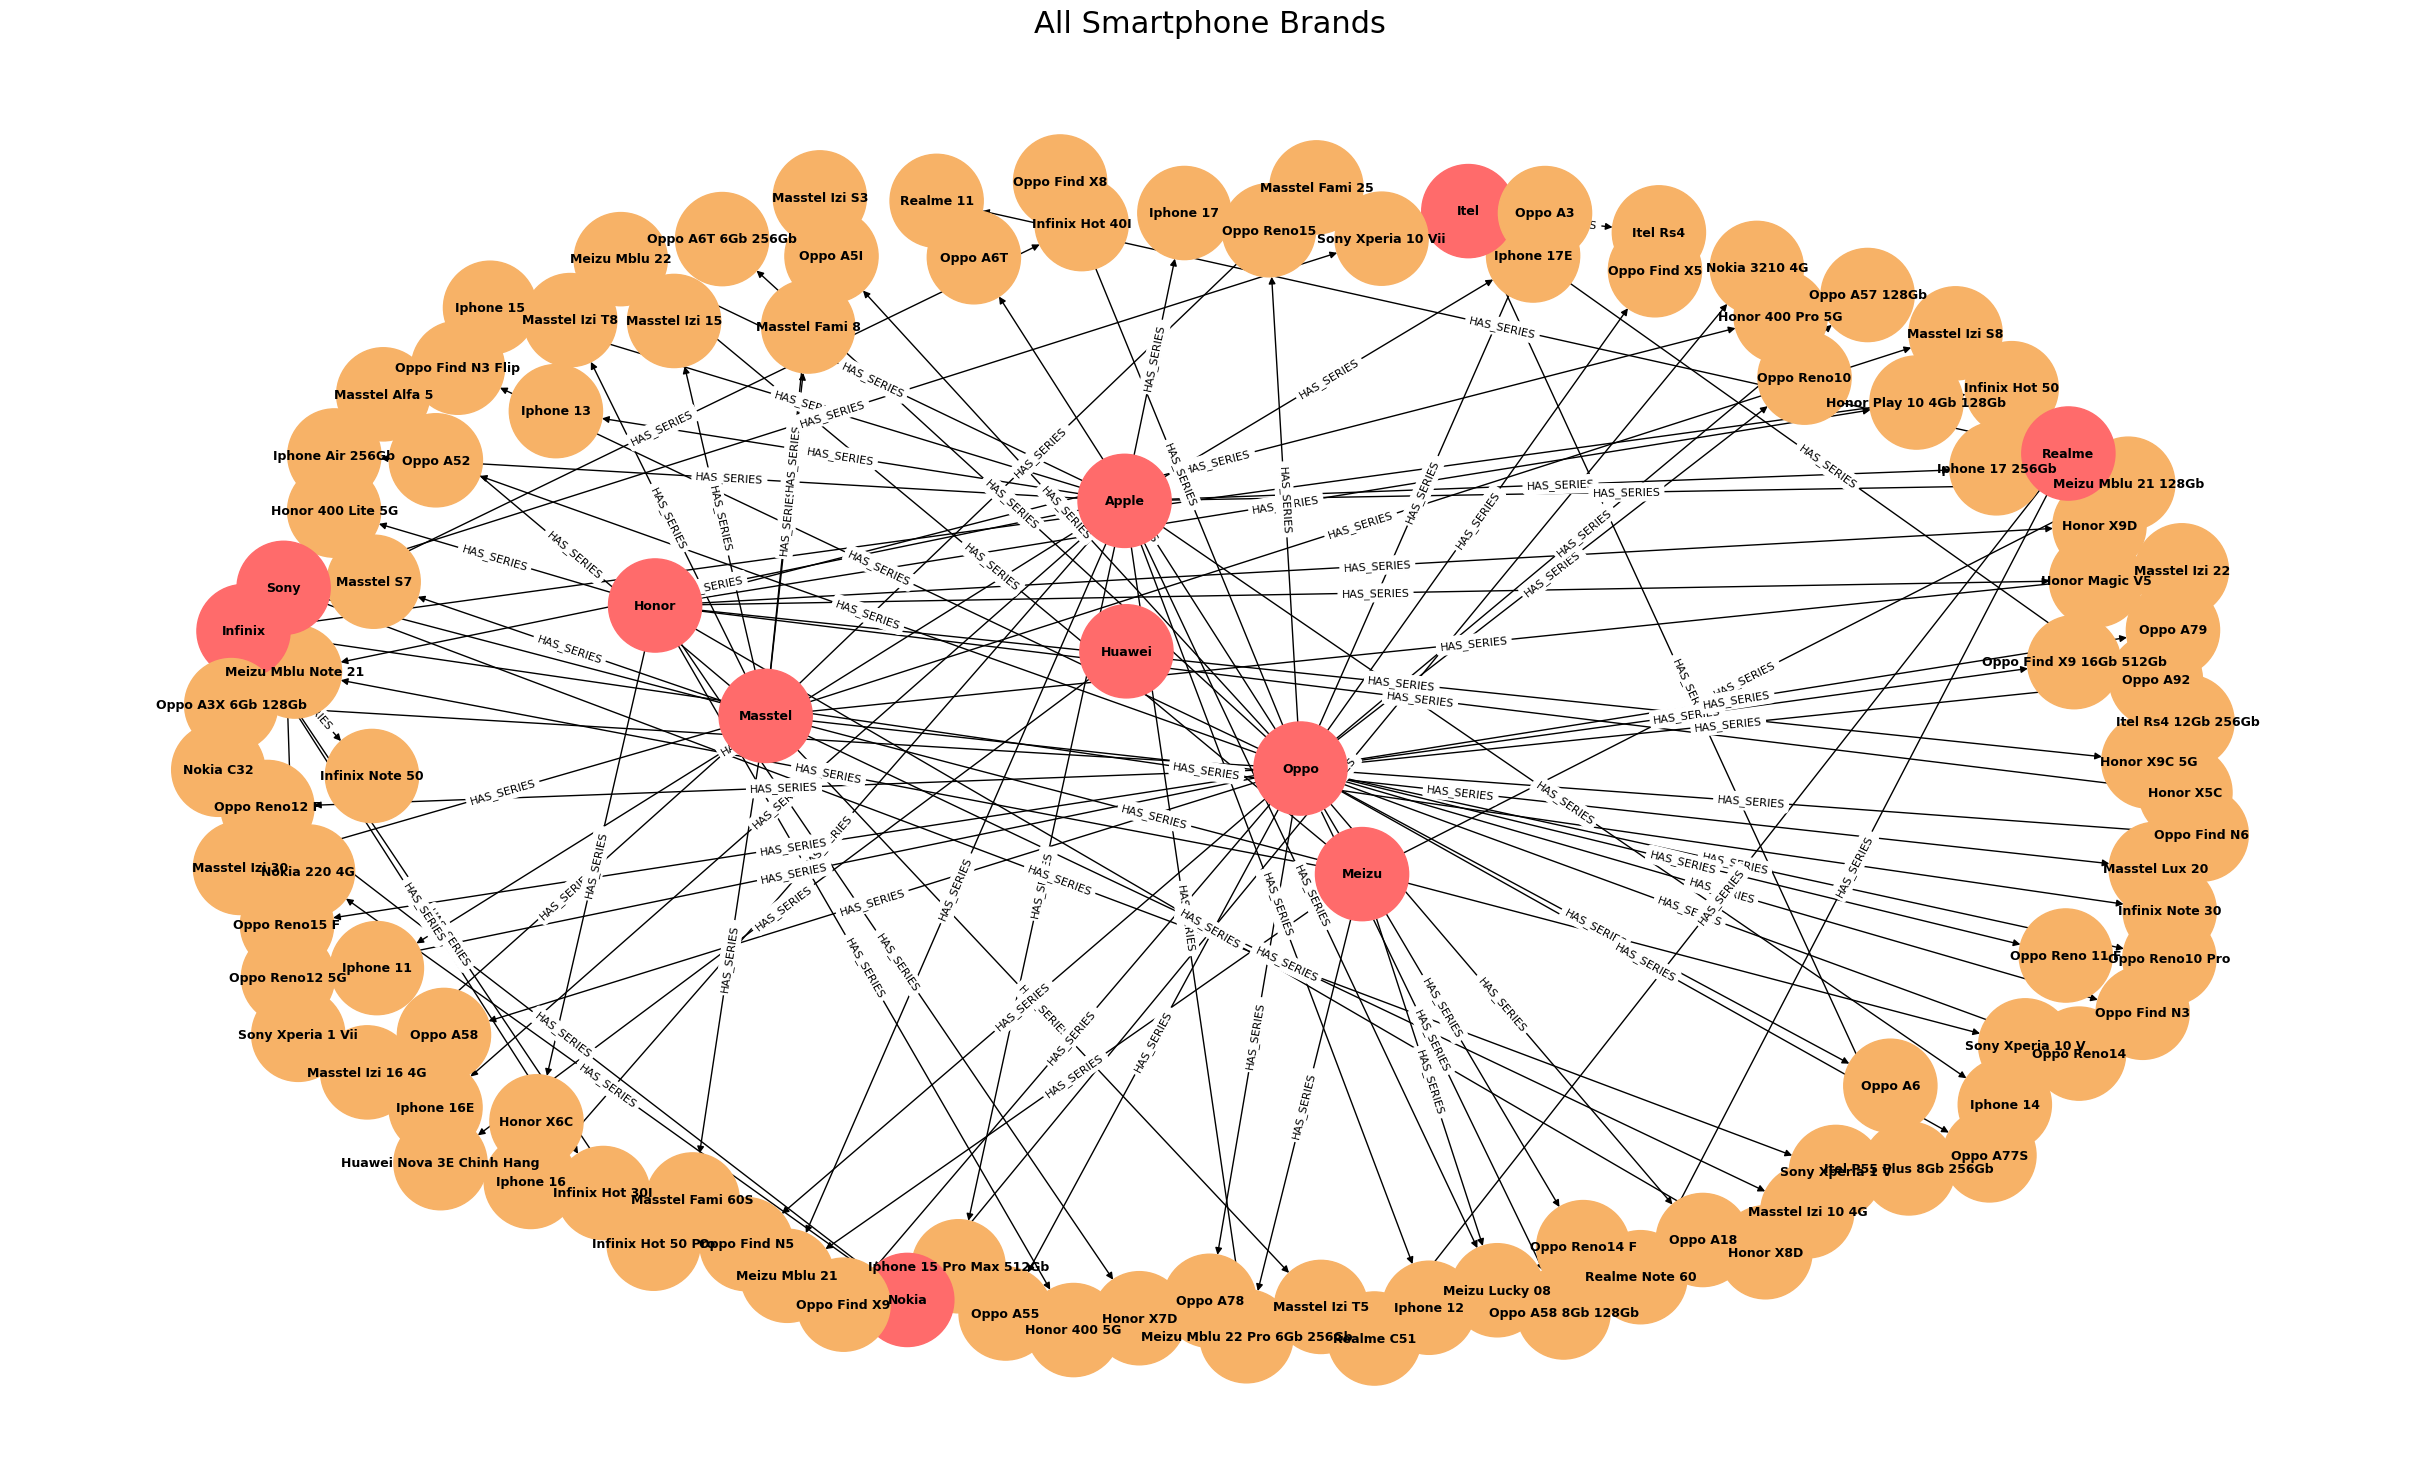

In [15]:
draw_neo4j_graph(
    """
    MATCH (a:Brand)-[r:HAS_SERIES]->(b:Series)
    RETURN a, r, b
    """,
    title="All Smartphone Brands"
)

In [16]:
draw_neo4j_graph(
    """
    MATCH
    (a:Brand {name:'Apple'})
    -[:HAS_SERIES]->
    (s:Series)

    RETURN a,
           {
             type:'HAS_SERIES'
           } AS r,
           s AS b

    UNION

    MATCH
    (:Brand {name:'Apple'})
    -[:HAS_SERIES]->
    (s:Series)
    -[:HAS_MODEL]->
    (m:Model)

    RETURN s AS a,
           {
             type:'HAS_MODEL'
           } AS r,
           m AS b

    UNION

    MATCH
    (:Brand {name:'Apple'})
    -[:HAS_SERIES]->
    (:Series)
    -[:HAS_MODEL]->
    (m:Model)
    -[:HAS_VARIANT]->
    (v:Variant)

    RETURN m AS a,
           {
             type:'HAS_VARIANT'
           } AS r,
           v AS b
    """,
    title="Apple Knowledge Graph",
    figsize=(28,16),
    k=2.0
)

AttributeError: 'dict' object has no attribute 'type'

In [ ]:
draw_neo4j_graph(
    """
    MATCH
    (m:Model {
        model_id:'iphone-17-pro-max'
    })
    -[r]->
    (b)

    WHERE
        b:Variant
        OR b:ColorVariant
        OR b:SpecCategory
        OR b:PhoneMeta
        OR b:QualityProfile
        OR b:UseCase
        OR b:TargetUser

    RETURN
        m AS a,
        r,
        b
    """,
    title="iPhone 17 Pro Max - Detailed Knowledge Graph",
    figsize=(28,18),
    k=2.2
)